<div style="display: flex; align-items: flex-start; justify-content: space-between;">
    <img src="LogoIUT.jpg" alt="Description" width="200">
    <div style="text-align: center; flex: 1; margin-top: 100px;">
        <h1>SAÉ Apprentissage pour l'IA<br>Projet</h1>
    </div>
    <div style="text-align: right;">
        BUT SD S6<br>
        2025 – 2026<br>
        NATHAN MANOHY
</div>

## Présentation du projet


In [4]:
# Imports et fonctions utiles
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from keras import layers
from pathlib import Path
from keras import layers
import os, pickle

MODEL_FOLDER ="../models"
RESULT_FOLDER ="../results"
Path(MODEL_FOLDER).mkdir(parents=True, exist_ok=True)
Path(RESULT_FOLDER).mkdir(parents=True, exist_ok=True)

def show_data_img(X, n=200, shape=(28,28), dpi=100):
    plt.figure(figsize=(7.195, 3.841), dpi=dpi)
    nl = n // 20
    if n%20!=0: nl += 1
    
    for i in range(n):
        plt.subplot(nl,20,i+1)
        plt.imshow(X[i,:].reshape(shape), cmap='gray')
        plt.axis('off')
    plt.plot()

def show_model_errors_rgb(model, X, y, shape=(32,32,3)):
    proba = model.predict(X)
    y_pred = proba.argmax(axis=1)
    errors = [i for i in range(len(y_pred)) if y_pred[i]!=y[i]]
    
    # Affichage manuel pour RGB
    X_err, y_pred_err, y_true_err = X[errors], y_pred[errors], y[errors]
    n = min(len(X_err), 30)
    
    plt.figure(figsize=(7.195, 3.841), dpi=100)
    nl = n // 10
    if n % 10 != 0: nl += 1
    
    for i in range(n):
        plt.subplot(nl, 10, i+1)
        plt.imshow(X_err[i])
        plt.axis('off')
        plt.title(str(y_pred_err[i]) + ' (' + str(y_true_err[i]) + ')', fontsize=8)
    
    plt.tight_layout()
    plt.show()   

Fonction pour que les graphiques soit plus propres

In [5]:
def plot_metrics(accuracy, loss):
    models = list(dict.fromkeys(
        k.replace('_train', '').replace('_test', '') 
        for k in accuracy.keys()
    ))
    
    palette = plt.cm.tab10.colors
    color_map = {model: palette[i % len(palette)] for i, model in enumerate(models)}
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
    for key, values in accuracy.items():
        is_train = '_train' in key
        model = key.replace('_train', '').replace('_test', '')
        ax1.plot(values,
                 label=key,
                 color=color_map[model],
                 linewidth=2 if is_train else 1.2,
                 linestyle='-' if is_train else '--')
    ax1.set_title("Evolution de l'accuracy au cours de l'entrainement")
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    for key, values in loss.items():
        is_train = '_train' in key
        model = key.replace('_train', '').replace('_test', '')
        ax2.plot(values,
                 label=key,
                 color=color_map[model],
                 linewidth=2 if is_train else 1.2,
                 linestyle='-' if is_train else '--')
    ax2.set_title("Evolution de la loss au cours de l'entrainement")
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()


## Etude 2 : Classement d'images sur les données CIFAR-10

In [6]:
from keras.datasets import cifar10 
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

In [7]:
X_train.shape

(50000, 32, 32, 3)

In [8]:
X_train = X_train / 255
X_test = X_test / 255

**Exemples d’images pour chaque classe**

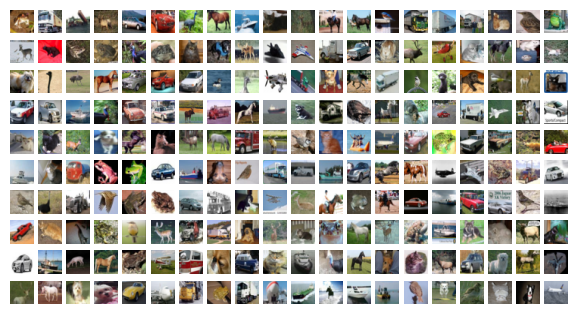

In [9]:
show_data_img(X_train, n=200, shape=(32,32,3), dpi=100)

**Répartition des classes**

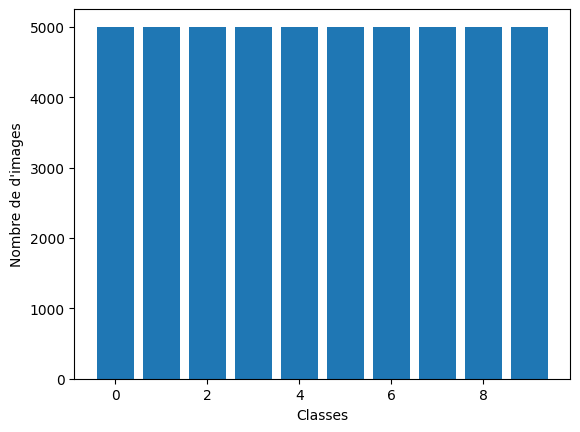

In [10]:
classes, counts = np.unique(y_train, return_counts=True)
plt.bar(classes, counts)
plt.xlabel("Classes")
plt.ylabel("Nombre de d'images")
plt.show()

In [11]:
accuracy = {}
loss = {}

In [12]:
def baseline():
    m = keras.models.Sequential()
    m.add(keras.layers.Input(shape=(32, 32, 3)))
    m.add(keras.layers.Flatten()) # Très utile car on est sur des données sur 3 cannals (le RGB)
    m.add(keras.layers.Dense(32, activation = 'relu'))
    m.add(keras.layers.Dense(10, activation= 'softmax'))

    m.compile(optimizer='SGD', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m, "baseline"

def avance_33():
    m = keras.models.Sequential()
    m.add(keras.layers.Input(shape=(32,32,3)))
    m.add(layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
    m.add(layers.MaxPooling2D(pool_size=(2,2)))
    m.add(layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
    m.add(layers.MaxPooling2D(pool_size=(2,2)))

    m.add(keras.layers.Flatten())
    m.add(keras.layers.Dense(10, activation='softmax'))

    m.compile(optimizer='adam',loss="sparse_categorical_crossentropy",metrics=['accuracy'])
    return m, "avance_33"


def avance_55():
    m = keras.models.Sequential()
    m.add(keras.layers.Input(shape=(32,32,3)))
    m.add(layers.Conv2D(32, kernel_size=(5,5), activation='relu'))
    m.add(layers.MaxPooling2D(pool_size=(2,2)))
    m.add(layers.Conv2D(64, kernel_size=(5,5), activation='relu'))
    m.add(layers.MaxPooling2D(pool_size=(2,2)))

    m.add(keras.layers.Flatten())
    m.add(keras.layers.Dense(10, activation='softmax'))

    m.compile(optimizer='adam',loss="sparse_categorical_crossentropy",metrics=['accuracy'])
    return m, "avance_55"


def avance_augmentation_55():
    m = keras.models.Sequential()
    m.add(keras.layers.Input(shape=(32,32,3)))
    
    m.add(layers.RandomFlip("horizontal"))
    m.add(layers.RandomRotation(0.05))

    
    m.add(layers.Conv2D(32, kernel_size=(5,5), activation='relu'))
    m.add(layers.MaxPooling2D(pool_size=(2,2)))
    m.add(layers.Conv2D(64, kernel_size=(5,5), activation='relu'))
    m.add(layers.MaxPooling2D(pool_size=(2,2)))

    m.add(keras.layers.Flatten())
    m.add(keras.layers.Dense(10, activation='softmax'))

    m.compile(optimizer='adam',loss="sparse_categorical_crossentropy",metrics=['accuracy'])
    return m, "avance55_V4"


def avance_augmentation_33():
    m = keras.models.Sequential()
    m.add(keras.layers.Input(shape=(32,32,3)))
    
    m.add(layers.RandomFlip("horizontal"))
    m.add(layers.RandomRotation(0.05))

    
    m.add(layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
    m.add(layers.MaxPooling2D(pool_size=(2,2)))
    m.add(layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
    m.add(layers.MaxPooling2D(pool_size=(2,2)))

    m.add(keras.layers.Flatten())
    m.add(keras.layers.Dense(10, activation='softmax'))

    m.compile(optimizer='adam',loss="sparse_categorical_crossentropy",metrics=['accuracy'])
    return m, "avance33_V5"

def LeNet5_V3():
    m = keras.models.Sequential()
    m.add(keras.layers.Input(shape=(32,32,3)))

    m.add(layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
    m.add(layers.MaxPooling2D(pool_size=(2,2)))
    m.add(layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
    m.add(layers.MaxPooling2D(pool_size=(2,2)))
    m.add(keras.layers.Flatten())
    m.add(keras.layers.Dropout(0.5))
    m.add(keras.layers.Dense(10, activation='softmax'))

    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m, "LeNet5_V3"


In [ ]:
models = [baseline,avance_33,avance_55,avance_augmentation_33,avance_augmentation_55, LeNet5_V3]
taille_batch = 64
nb_iterations = 100

for model_func in models:
    model, nom = model_func()
    print(f"\n=== Entrainement de {nom} ===")
    model.summary()
    
    s = model.fit(X_train, y_train, batch_size=taille_batch, epochs=nb_iterations, verbose=1, validation_data=(X_test, y_test),callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)])
    
    accuracy[nom+"_train"] = s.history['accuracy']
    accuracy[nom+"_test"] = s.history['val_accuracy']
    
    loss[nom+"_train"] = s.history['loss']
    loss[nom+"_test"] = s.history['val_loss']
    
    model.save(MODEL_FOLDER+"/CIFAR_"+nom+".keras")
    print(f"{nom} sauvegardé")

    with open(RESULT_FOLDER+"/CIFAR_accuracy_"+nom+".pickle", "wb") as f:
        pickle.dump({"train": s.history['accuracy'], "val": s.history['val_accuracy']}, f)
    
    with open(RESULT_FOLDER+"/CIFAR_loss_"+nom+".pickle", "wb") as f:
        pickle.dump({"train": s.history['loss'], "val": s.history['val_loss']}, f)


=== Entrainement de baseline ===


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │        98,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 98,666 (385.41 KB)

 Trainable params: 98,666 (385.41 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 10, 10, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,706 (272.29 KB)

 Trainable params: 69,706 (272.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4192 - loss: 1.6143 - val_accuracy: 0.4962 - val_loss: 1.3962
Epoch 2/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5298 - loss: 1.3275 - val_accuracy: 0.5673 - val_loss: 1.2088
Epoch 3/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5737 - loss: 1.2154 - val_accuracy: 0.5955 - val_loss: 1.1511
Epoch 4/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6032 - loss: 1.1405 - val_accuracy: 0.6207 - val_loss: 1.0809
Epoch 5/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6215 - loss: 1.0849 - val_accuracy: 0.6363 - val_loss: 1.0393
Epoch 6/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6379 - loss: 1.0430 - val_accuracy: 0.6409 - val_loss: 1.0377
Epoch 7/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6484 - loss: 1.0097 - val_accuracy: 0.6488 - val_loss: 1.0095
Epoch 8/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6608 - loss: 0.9803 - val_accu

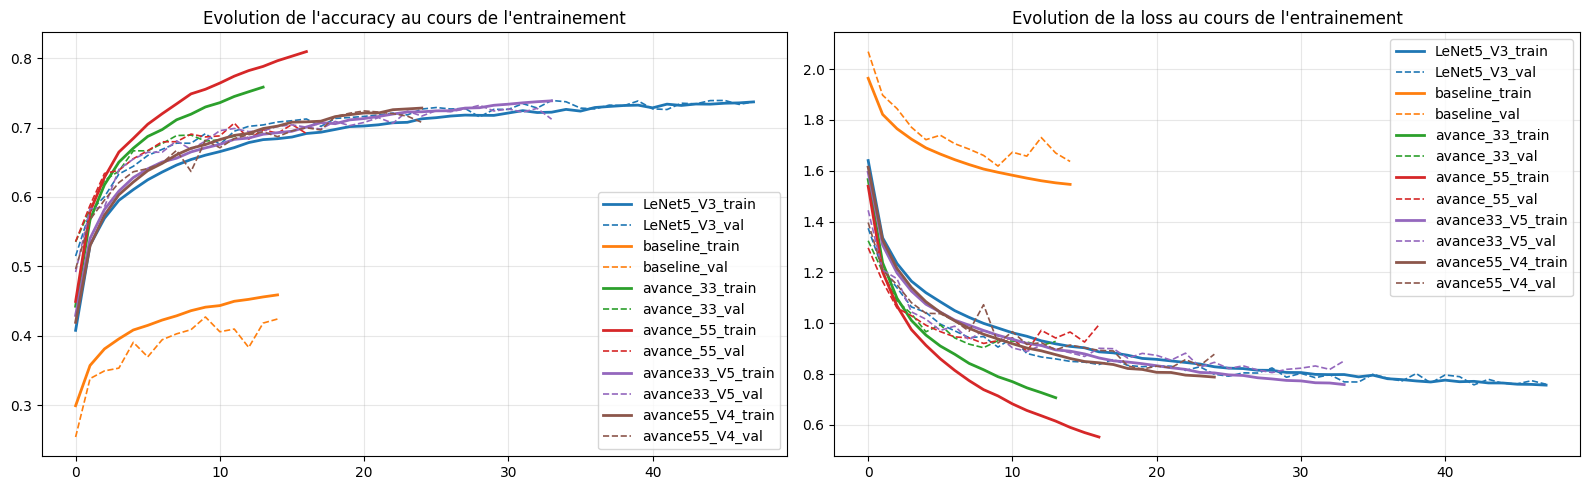

In [ ]:
plot_metrics(accuracy, loss)

In [13]:
from keras.models import load_model

In [14]:
meilleur_model = load_model(MODEL_FOLDER+"/CIFAR_avance33_V5.keras")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 877us/step


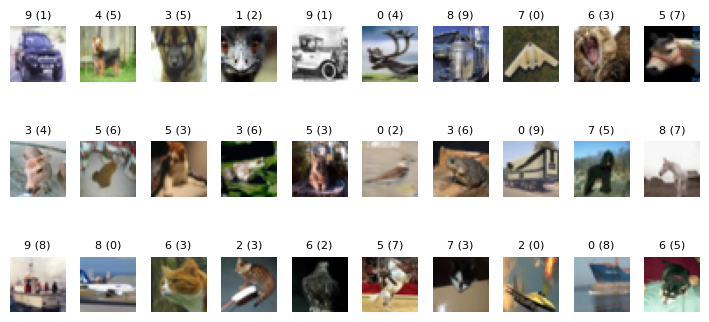

In [15]:
# Afficher ses erreurs
show_model_errors_rgb(meilleur_model, X_test, y_test.flatten())

# Si besoin de recharger des modèles pour en ajouter

In [ ]:
from keras.models import load_model

# Recharger les résultats pickle
accuracy = {}
loss = {}

models_noms = ['baseline', 'avance_33', 'avance_55', 'avance33_V5', 'avance55_V4','LeNet5_V3']

for nom in models_noms:
    acc_path = RESULT_FOLDER + f"/CIFAR_accuracy_{nom}.pickle"
    loss_path = RESULT_FOLDER + f"/CIFAR_loss_{nom}.pickle"
    if os.path.exists(acc_path):
        with open(acc_path, "rb") as f:
            data = pickle.load(f)
            accuracy[nom+"_train"] = data["train"]
            accuracy[nom+"_test"] = data["val"]
        print(f"{nom} accuracy chargé ✓")
    else:
        print(f"⚠️ {nom} accuracy introuvable")
    
    if os.path.exists(loss_path):
        with open(loss_path, "rb") as f:
            data = pickle.load(f)
            loss[nom+"_train"] = data["train"]
            loss[nom+"_test"] = data["val"]
        print(f"{nom} loss chargé ✓")
    else:
        print(f"⚠️ {nom} loss introuvable")

baseline accuracy chargé ✓
baseline loss chargé ✓
avance_33 accuracy chargé ✓
avance_33 loss chargé ✓
avance_55 accuracy chargé ✓
avance_55 loss chargé ✓
avance33_V5 accuracy chargé ✓
avance33_V5 loss chargé ✓
avance55_V4 accuracy chargé ✓
avance55_V4 loss chargé ✓
LeNet5_V3 accuracy chargé ✓
LeNet5_V3 loss chargé ✓


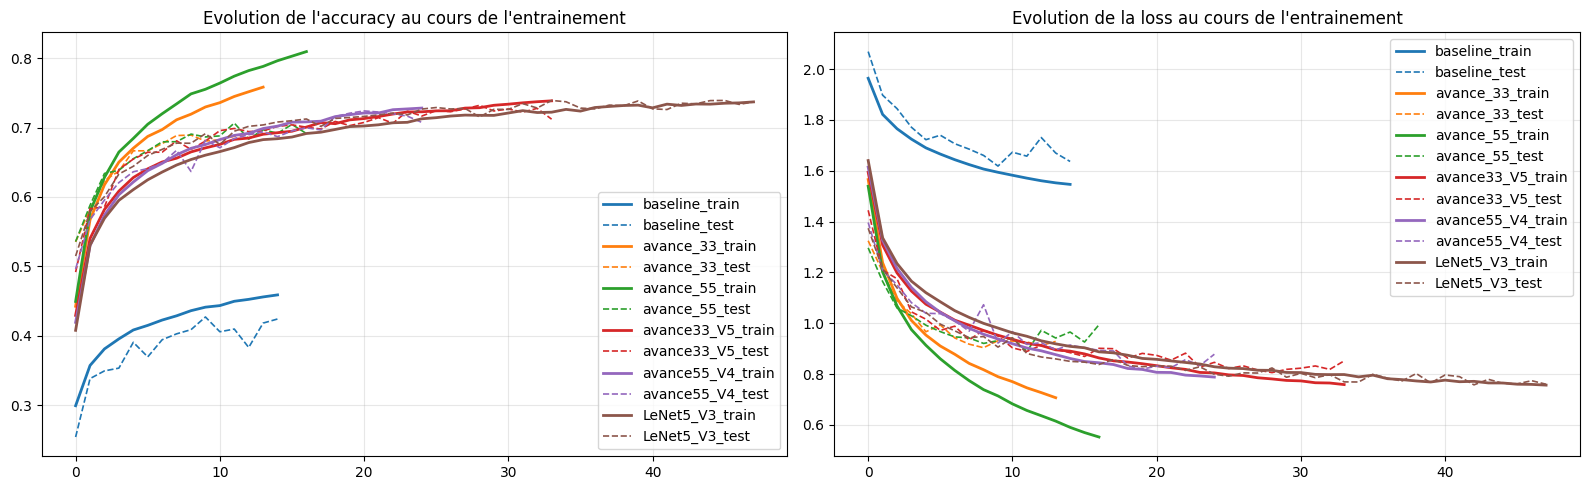

In [17]:
plot_metrics(accuracy, loss)

In [18]:
meilleur_model = load_model(MODEL_FOLDER+"/CIFAR_avance33_V5.keras")
score = meilleur_model.evaluate(X_test,y_test , batch_size = 64, verbose =1)
score

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7321 - loss: 0.8059


[0.805910050868988, 0.7321000099182129]

# Bonus : Faire une analyse des confusions entre chat et chien.

Étape 1 – Obtenir les prédictions

In [22]:
y_pred = meilleur_model.predict(X_test)
y_pred_classes = y_pred.argmax(axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 878us/step


Étape 2 – Matrice de confusion

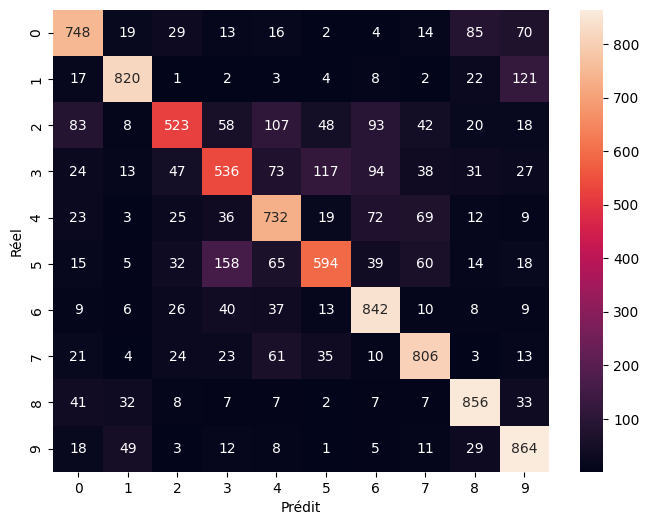

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

On voit qu'a part la diagonnale de bonne réponse la valeurs sur laquel le modèle se trompe le plus sont les (3,5) ou bien (5,3), les 3 = chats et les 5 = chiens

Étape 3 – Isoler chat et chien

In [ ]:
import numpy as np
y_test = y_test.flatten() # Applatir le y test 
cat_label = 3
dog_label = 5

# indices des chats mal classés en chiens
cat_as_dog = np.where((y_test == cat_label) & (y_pred_classes == dog_label))[0]

# indices des chiens mal classés en chats
dog_as_cat = np.where((y_test == dog_label) & (y_pred_classes == cat_label))[0]

[ 61  68 143 184 323 356 669 671 739 870]


Étape 4 – Afficher des exemples

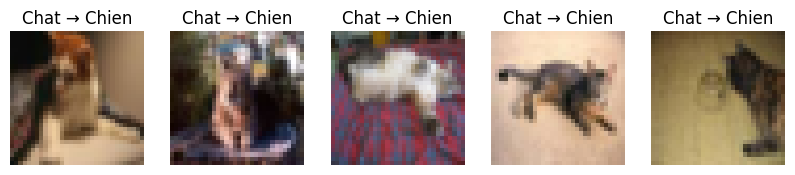

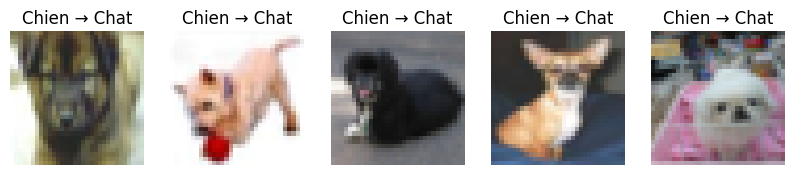

In [28]:
def show_images(indices, title):
    plt.figure(figsize=(10,4))
    for i, idx in enumerate(indices[:5]):
        plt.subplot(1,5,i+1)
        plt.imshow(X_test[idx])
        plt.title(title)
        plt.axis("off")
    plt.show()

show_images(cat_as_dog, "Chat → Chien")
show_images(dog_as_cat, "Chien → Chat")